<a href="https://colab.research.google.com/github/ManMohanit/Deep-Learning/blob/main/Energy_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
import numpy as np

In [25]:
df = pd.read_csv("powerplant_data.csv")

In [26]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [27]:
# AT =>Temperature
# V =>vaccum
# AP => Pressure
# Rh => humidity

# PE =>produced energy

In [28]:
df.isnull().sum()

,0
AT,0
V,0
AP,0
RH,0
PE,0


In [29]:
X = df.drop(columns = ["RH"], axis = 1)
y = df["RH"]

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
# Converting data to tensors
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype = torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.float32).view(-1, 1)

In [33]:
# Dataloader ===>> makes batches and shuffle
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = True)

In [34]:
#Deep Learning

In [35]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.model = nn.Sequential(
        # 1st hidden layer
        nn.Linear(X_train.shape[1], 6),
        nn.ReLU(),

        # 2nd hidden layer
        nn.Linear(6, 6),
        nn.ReLU(),

        #output layer
        nn.Linear(6, 1)
    )

    def forward(self, x):
        return self.model(x)

In [36]:
import torch.optim as optim
model = ANN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [37]:
# Train the ANN

train_losses = []
val_losses = []

epochs = 50
best_val_loss = float("inf")

for epoch in range(epochs):

    model.train()

    running_loss = 0.0

    for xb, yb in train_loader:

        optimizer.zero_grad()

        output = model(xb)

        loss = criterion(output, yb)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    # IMPORTANT: inside epoch loop
    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for xb, yb in test_loader:

            output = model(xb)

            loss = criterion(output, yb)

            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"==> train loss = {epoch_train_loss:.4f} "
        f"& val loss = {epoch_val_loss:.4f}"
    )


    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss

        torch.save(
            model.state_dict(),
            "best_model.pth"
        )

Epoch 1/50 ==> train loss = 5577.0900 & val loss = 5284.1132
Epoch 2/50 ==> train loss = 4526.8884 & val loss = 3257.7454
Epoch 3/50 ==> train loss = 2098.7812 & val loss = 1199.4640
Epoch 4/50 ==> train loss = 812.4150 & val loss = 607.1361
Epoch 5/50 ==> train loss = 510.0211 & val loss = 443.6296
Epoch 6/50 ==> train loss = 384.0332 & val loss = 345.2291
Epoch 7/50 ==> train loss = 301.4200 & val loss = 270.7079
Epoch 8/50 ==> train loss = 236.7402 & val loss = 215.6213
Epoch 9/50 ==> train loss = 192.2217 & val loss = 180.4602
Epoch 10/50 ==> train loss = 163.4088 & val loss = 157.7227
Epoch 11/50 ==> train loss = 145.9723 & val loss = 143.2844
Epoch 12/50 ==> train loss = 133.8797 & val loss = 133.5804
Epoch 13/50 ==> train loss = 126.6314 & val loss = 126.9418
Epoch 14/50 ==> train loss = 121.6250 & val loss = 121.8769
Epoch 15/50 ==> train loss = 117.0400 & val loss = 117.8703
Epoch 16/50 ==> train loss = 114.8683 & val loss = 115.6559
Epoch 17/50 ==> train loss = 113.2764 & val

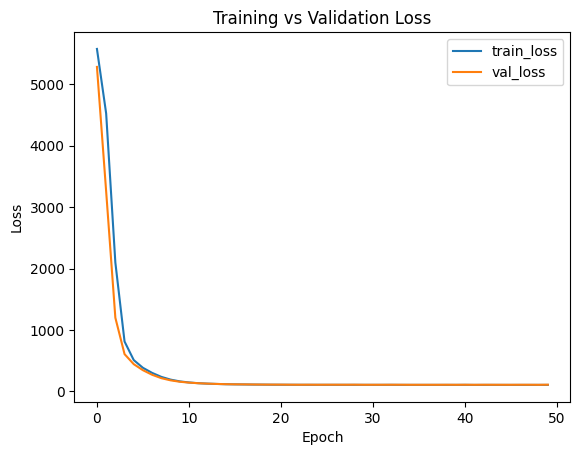

In [38]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "train_loss": train_losses,
    "val_loss": val_losses
})

loss_df.plot()

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.show()